In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
from astropy.io import fits
import numpy as np


# SWIFT GRB Table

In [3]:
# check data dir
os.listdir('../data')

['sed_Fnu_grb_0.txt',
 'Fermi_LAT_GRB_Catalog.fits',
 'Swift_GRB_Table_04012022.txt']

In [4]:
# get Swift table
swift_table = "../data/Swift_GRB_Table_04012022.txt"

In [5]:
frame = pd.read_csv(swift_table, sep='\t') 
frame.head()

,GRB,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],XRT RA (J2000),XRT Dec (J2000),XRT Time to First Observation [sec],...,UVOT RA (J2000),UVOT Dec (J2000),UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,Redshift,Host Galaxy,Comments,References
0,220325A,17:16:23,1099310,269.469,-7.055,3.50,2.9,17:57:57.00,-07:02:09.3,110.16,...,NaN,NaN,114,V>18.7,B>20.1|U>20.3|UVW1>17.9|White>21.0,Fermi (GBM Sub-Threshold),NaN,NaN,NaN,NaN
1,220319A,17:40:33,1098132,218.139,61.291,6.44,2.3,14:32:53.86,61:17:43.3,101.21,...,NaN,NaN,317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,220306B,18:15:37,1095288,5.380,71.384,12.34,6.0,00:21:33.10,71:21:49.0,85.89,...,NaN,NaN,89,V>18.7,B>19.9|U>20.2|UVW1>19.3|UVM2>19.4|UVW2>19.4|Wh...,Fermi (GBM),NaN,NaN,NaN,NaN
3,220305A,16:13:08,1095215,107.610,-37.703,21.12,20,07:10:23.65,-37:40:49.2,3016.95,...,NaN,NaN,NaN,NaN,NaN,Fermi (GBM sub-threshold),NaN,NaN,"Due to an observing constraint, Swift did not ...",NaN
4,220302A,07:40:19,1094950,301.432,49.389,NaN,NaN,20:05:43.30,49:23:13.1,32459.26,...,NaN,NaN,32464,V>19.2,UVM2>19.7|White>19.9,NaN,NaN,NaN,Swift is currently restarting after a reaction...,NaN


In [6]:
frame.columns

Index(['GRB', 'Time [UT]', 'Trigger Number', 'BAT RA (J2000)',
       'BAT Dec (J2000)', 'BAT T90 [sec]',
       'BAT Fluence (15-150 keV) [10^-7 erg/cm^2]', 'XRT RA (J2000)',
       'XRT Dec (J2000)', 'XRT Time to First Observation [sec]',
       'XRT Early Flux (0.3-10 keV) [10^-11 erg/cm^2/s]',
       'XRT Column Density (NH) [10^21 cm^-2]', 'UVOT RA (J2000)',
       'UVOT Dec (J2000)', 'UVOT Time to First Observation [sec]',
       'UVOT Magnitude', 'UVOT Other Filter Magnitudes',
       'Other Observatory Detections', 'Redshift', 'Host Galaxy', 'Comments',
       'References'],
      dtype='object')

In [7]:
frame.fillna(value=-1)

,GRB,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],XRT RA (J2000),XRT Dec (J2000),XRT Time to First Observation [sec],...,UVOT RA (J2000),UVOT Dec (J2000),UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,Redshift,Host Galaxy,Comments,References
0,220325A,17:16:23,1099310,269.469,-7.055,3.50,2.9,17:57:57.00,-07:02:09.3,110.16,...,-1,-1,114,V>18.7,B>20.1|U>20.3|UVW1>17.9|White>21.0,Fermi (GBM Sub-Threshold),-1,-1,-1,-1.0
1,220319A,17:40:33,1098132,218.139,61.291,6.44,2.3,14:32:53.86,61:17:43.3,101.21,...,-1,-1,317,-1,-1,-1,-1,-1,-1,-1.0
2,220306B,18:15:37,1095288,5.380,71.384,12.34,6.0,00:21:33.10,71:21:49.0,85.89,...,-1,-1,89,V>18.7,B>19.9|U>20.2|UVW1>19.3|UVM2>19.4|UVW2>19.4|Wh...,Fermi (GBM),-1,-1,-1,-1.0
3,220305A,16:13:08,1095215,107.610,-37.703,21.12,20,07:10:23.65,-37:40:49.2,3016.95,...,-1,-1,-1,-1,-1,Fermi (GBM sub-threshold),-1,-1,"Due to an observing constraint, Swift did not ...",-1.0
4,220302A,07:40:19,1094950,301.432,49.389,-1,-1,20:05:43.30,49:23:13.1,32459.26,...,-1,-1,32464,V>19.2,UVM2>19.7|White>19.9,-1,-1,-1,Swift is currently restarting after a reaction...,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521,041220,22:58:27,100433,291.288,60.598,5.600,3.83,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,BAT: FRED|No AT slew|XRT: no observation|UVOT:...,-1.0
1522,041219C,20:30:34,100380*,343.926,-76.744,4.800,13.10,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,BAT: 3 spikes|No AT slew|XRT: no observation|U...,-1.0
1523,041219B,15:38:48,100367*,167.674,-33.458,30,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,IPN,-1,-1,"BAT: 1 big spike, 3 little spikes|No AT slew|X...",-1.0
1524,041219A,01:42:18,100307|100319,6.154,62.847,520,1550,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,"BAT: bright, long, multipeaked|No AT slew|XRT:...",-1.0


In [8]:
good_z = list()
for z in frame['Redshift'].values:
    try:
        good_z.append(float(z.split()[0][:4]))
        print(z.split()[0][:4])
    except:
        pass

4.96
1.24
4.61
2.27
1.11
0.86
6.31
1.73
1.25
1.14
1.17
1.93
1.13
3.54
2.48
2.07
1.40
2.82
1.48
2.19
0.71
1.04
5.70
1.10
1.95
0.99
1.07
2.90
0.42
4.56
1.25
0.4
1.46
1.19
0.24
1.72
3.50
0.07
2.46
1.94
1.17
0.42
3.37
1.86
1.50
2.93
1.39
0.11
0.65
2.85
1.11
1.30
1.00
1.99
2.25
1.44
1.40
2.48
2.40
0.03
1.87
0.88
0.79
2.01
0.55
1.32
2.36
0.81
3.51
3.64
1.96
0.14
0.64
1.54
1.15
2.01
2.82
0.73
0.48
0.55
1.71
4.99
0.72
2.38
3.52
0.97
1.96
0.87
2.59
4.1
3.5
1.16
1.42
4.06
0.38
2.33
1.96
1.35
0.75
0.28
0.31
1.39
3.2
2.06
0.59
1.75
1.51
2.08
0.46
0.09
0.91
1.45
1.31
0.59
1.47
2.99
3.35
0.57
1.21
0.35
0.55
3.14
2.27
4.23
4.70
6.32
0.72
0.88
1.60
3.26
3.95
1.02
4.95
5.28
1.41
1.20
2.73
3.0
4.18
1.68
0.59
1.29
0.71
0.34
1.23
0.47
1.15
2.00
2.09
5.91
1.06
0.35
2.49
3.6
1.30
2.27
2.78
0.34
1.29
1.21
3.75
0.59
2.53
2.70
1.02
3.38
2.20
1.77
2.29
3.1
3.93
0.97
2.35
2.67
3.1
3.79
0.80
1.48
0.95
0.39
4.0
0.28
2.87
2.81
1.79
1.72
2.94
1.38
0.71
0.29
0.67
3.15
2.89
5.0
3.36
1.34
1.85
2.83
1.03
0.82
1.61
1.77


In [9]:
plt.rcParams["figure.figsize"] = [9, 6]

Text(0, 0.5, 'N GRBs')

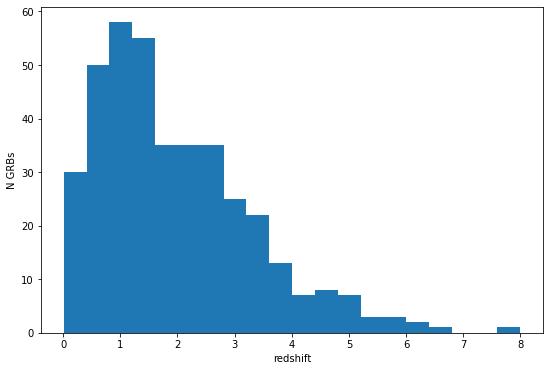

In [10]:
plt.hist(good_z, bins=20)
plt.xlabel("redshift")
plt.ylabel("N GRBs")

In [11]:
good_t90 = list()
for z in frame['BAT T90 [sec]'].values:
    try:
        good_t90.append(float(z))
        print(z)
    except:
        pass

3.50
6.44
12.34
21.12
nan
nan
nan
10.61
8.55
24.37
49.81
nan
173.36
nan
83.79
121.54
15.00
671.67
51.37
3.73
113.01
nan
1.75
103.5
603.5
nan
1.30
11.81
0.16
28.35
nan
46.77
nan
37.55
180.8
196.8
73.56
89.97
156.30
22.51
3.86
0.39
48.00
53.54
50.57
48.54
50.20
136.41
298.43
2.77
nan
138.2
nan
nan
60.90
2.13
69.38
13.62
nan
nan
63.21
3.06
55.7
70.21
8.22
135.06
11.53
39.00
nan
79.52
158.8
73.00
64.43
1.088
12.80
52.88
168.3
238.7
nan
1.12
8.21
14.95
48.00
5.3
262
24.32
9.12
68.6
20.80
12.82
240
4.22
80.0
6.1
6.60
139.4
95.69
22.70
0.06
107.60
19.94
32.06
87.25
53.3
nan
29.0
0.16
44.5
48.0
nan
nan
48.0
12.18
nan
5.41
33.82
8.66
120.55
546.73
135.38
5.00
24.38
14.17
22.08
9.78
36.2
7.36
0.49
15.2
18.25
10.30
76.0
19.4
16.9
0.83
70.90
24.15
705.94
20.37
13.04
23.62
nan
38.8
122.0
86
nan
nan
48.98
29.39
38.9
14.83
nan
171.48
119.2
79.57
58.7
0.62
71.88
74.0
828.2
81.0
5.04
0.22
108.8
17.91
nan
nan
nan
53.5
32.87
94.2
7.37
nan
32.8
45.0
288.0
81.3
nan
11.7
458.0
32.74
216.9
350.83
174.96
158.

Text(0, 0.5, 'N GRBs')

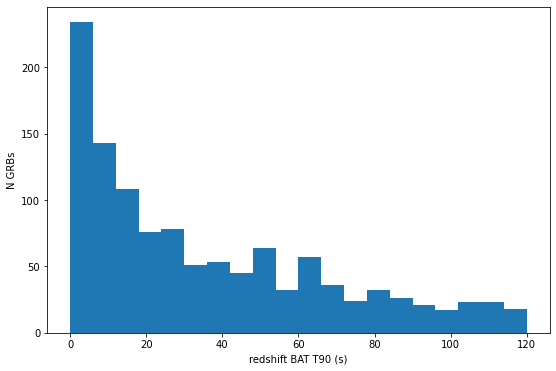

In [12]:
plt.hist(good_t90, bins=20, range=[0, 120])
plt.xlabel("redshift BAT T90 (s)")
plt.ylabel("N GRBs")

In [13]:
good_nh = list()
for z in frame['XRT Column Density (NH) [10^21 cm^-2]'].values:
    try:
        good_nh.append(float(z))
        print(z)
    except:
        pass

4.39183
2.80646
7.1463
7.71926
3.44325000011207
nan
nan
0.2253410139
nan
2.96395
9.89303
0.691213
8.01125
nan
3.151421
nan
nan
10.52106
0.175636808325
1.7
5.9
1.6
nan
0.24
0.97
nan
0.98
6.1695454
1.563605535
1.176304
28.7875
1.664012
0.87576
6.690287
3.41368
0.358588252885
1.936681
59.55983
3.43973379698
0.832807
6.718909
3.328428
4.567086
0.798344
0.823193683175
16.4046
0.347208
0.8887120253589
nan
2.94764
0.967706481
2.26212
1.745598
nan
6.82815
nan
1.09095
2.25621
1.703881
8.647074
6.248813
1.43775
0.671947
4.705422
0.71063659998
4.26977e-05
nan
nan
nan
4.6287300826473
6.23475e-08
2.256302
1.909034
nan
1.14806
0.660249
nan
3.459142
nan
2.86269
4.78789
16.0
1.436017
nan
nan
nan
nan
4.0
1.856992
1.4
12.09147
2.456848
136.63529
6.45772
1.327992
3.666260039488
0.719464
8.93527
nan
2.8528583
11.28593
1.244672
nan
1.312459
nan
0.4063472
3.46299e-11
72.9997
5.6
nan
nan
1.609313
0.1765696557
nan
1.537474
nan
5.37756
2.695375
1.325279
4.51195
1.698663
0.564931
0.856219
15.69767
2.26653
14.20

Text(0, 0.5, 'N GRBs')

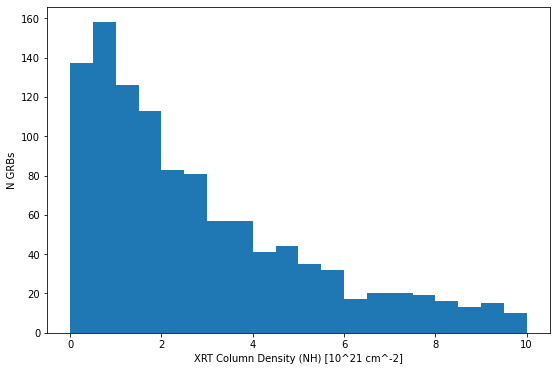

In [14]:
plt.hist(good_nh, bins=20, range=[0, 10])
plt.xlabel("XRT Column Density (NH) [10^21 cm^-2]")
plt.ylabel("N GRBs")

# FERMI LAT GRB Table



In [15]:
fermi = "/home/bregeon/Rubin/FINK/orphans/data/Fermi_LAT_GRB_Catalog.fits"

In [16]:
hdul = fits.open(fermi)
hdul.info()

Filename: /home/bregeon/Rubin/FINK/orphans/data/Fermi_LAT_GRB_Catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    310   186R x 116C   [30A, 30A, 30A, D, E, E, E, E, E, E, E, E, E, 30A, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, 12A, D, D, D, PD(97), PD(97), PD(97), PD(97), PD(97), PD(97), PD(97), PD(97), PD(97), PD(97), PD(97)]   


In [17]:
hdul[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  636 / length of dimension 1                          
NAXIS2  =                  186 / length of dimension 2                          
PCOUNT  =               359920 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                  116 / number of table fields                         
TTYPE1  = 'GCNNAME '                                                            
TFORM1  = '30A     '                                                            
TTYPE2  = 'GRBNAME '                                                            
TFORM2  = '30A     '                                                            
TTYPE3  = 'GRBDATE '        

Text(0, 0.5, 'N GRBs')

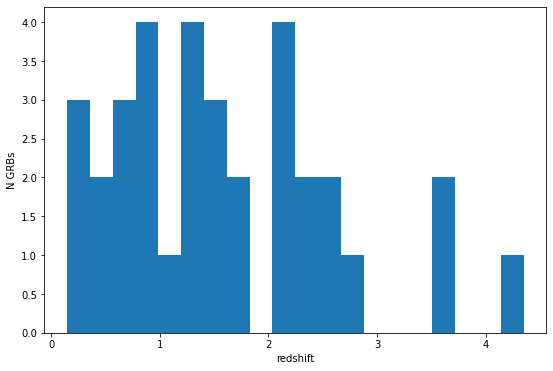

In [18]:
lat_z = hdul[1].data['REDSHIFT']
godd_lat_z = lat_z[lat_z>0]
plt.hist(godd_lat_z, bins=20)
plt.xlabel('redshift')
plt.ylabel("N GRBs")

Text(0, 0.5, 'N GRBs')

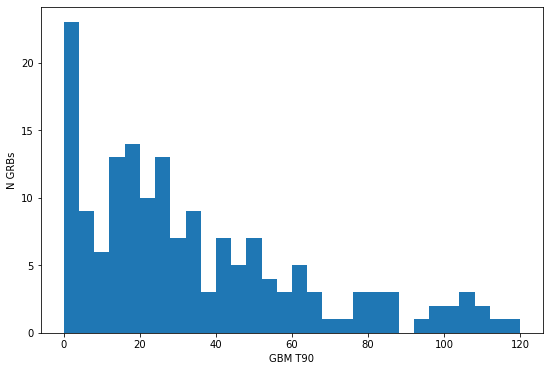

In [19]:
lat_t90 = hdul[1].data['GBMT90']
good_lat_t90 = lat_t90[lat_t90>0]
plt.hist(good_lat_t90, bins=30, range=[0, 120])
plt.xlabel('GBM T90')
plt.ylabel("N GRBs")

In [24]:
len(good_lat_t90)

186

Text(0, 0.5, 'N GRBs')

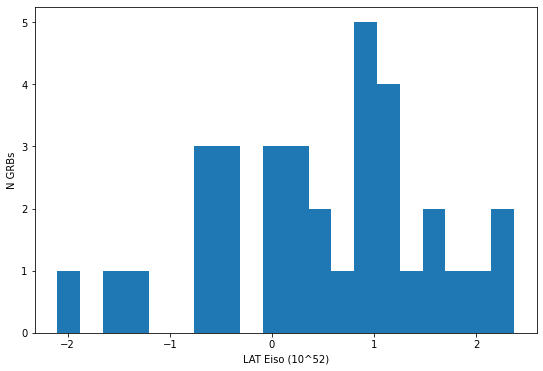

In [20]:
lat_Eiso = hdul[1].data['LIKE_LAT_EISO52_RF']
good_lat_Eiso = lat_Eiso[lat_Eiso>0]
plt.hist(np.log10(good_lat_Eiso), bins=20)
plt.xlabel('LAT Eiso (10^52)')
plt.ylabel('N GRBs')

Text(0, 0.5, 'N GRBs')

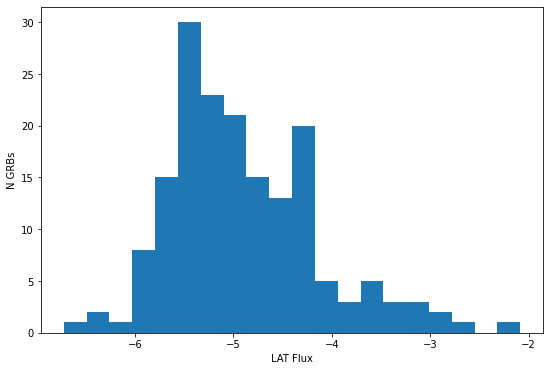

In [27]:
lat_flux = hdul[1].data['LIKE_LAT_FLUX']
good_lat_flux = lat_flux[lat_flux>0]
plt.hist(np.log10(good_lat_flux), bins=20)
plt.xlabel('LAT Flux')
plt.ylabel('N GRBs')



Text(0, 0.5, 'N GRBs')

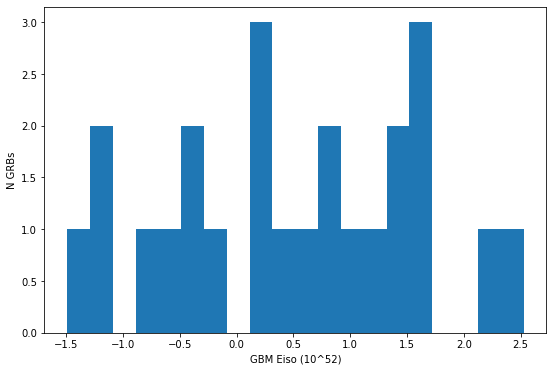

In [21]:
gbm_Eiso = hdul[1].data['LIKE_GBM_EISO52_RF']
good_gbm_Eiso = gbm_Eiso[gbm_Eiso>0]
plt.hist(np.log10(good_gbm_Eiso), bins=20)
plt.xlabel('GBM Eiso (10^52)')
plt.ylabel('N GRBs')


Text(0, 0.5, 'N GRBs')

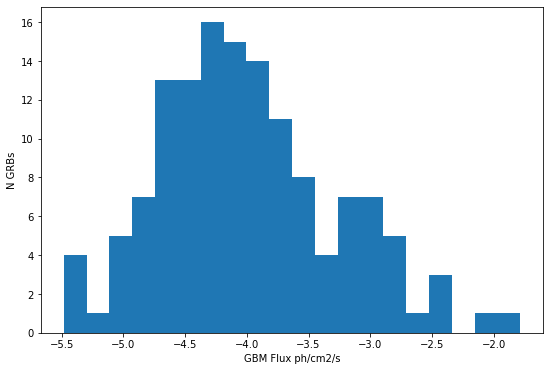

In [26]:
gbm_flux = hdul[1].data['LIKE_GBM_FLUX']
good_gbm_flux = gbm_flux[gbm_flux>0]
plt.hist(np.log10(good_gbm_flux), bins=20)
plt.xlabel('GBM Flux ph/cm2/s')
plt.ylabel('N GRBs')


